# Exploratory Data Analysis


## Database Connection

In [2]:
import pyodbc
import pandas as pd

# Define connection parameters
server = 'BALU'       # Or 'localhost\SQLEXPRESS' if using Express edition
database = 'ac'  # Change this to your actual database name

# Build the connection string using Windows Authentication
conn_str = (
    f"Driver={{SQL Server}};"
    f"Server={server};"
    f"Database={database};"
    f"Trusted_Connection=yes;"
)

# Connect to the database
conn = pyodbc.connect(conn_str)
print("Connected successfully!")

Connected successfully!


## Data Understanding

In [3]:
# SQL query to fetch all user-defined tables
query_tables = """
SELECT TABLE_SCHEMA, TABLE_NAME 
FROM INFORMATION_SCHEMA.TABLES 
WHERE TABLE_TYPE = 'BASE TABLE'
"""

# Load the list into a DataFrame
df_tables = pd.read_sql(query_tables, conn)

# Display the tables
df_tables

C:\Users\Admin\AppData\Local\Temp\ipykernel_15452\2874347726.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(query_tables, conn)


,TABLE_SCHEMA,TABLE_NAME
0,dbo,geo
1,dbo,people
2,dbo,products
3,dbo,sales


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading primary data table into a DataFrame
# (Replace 'sales' with other table name from df_tables)
table_name = "sales" 
query_main = f"SELECT * FROM {table_name}"
df = pd.read_sql(query_main, conn)

print(f"--- Data Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns ---\n")



Matplotlib is building the font cache; this may take a moment.


--- Data Loaded Successfully: 7617 rows, 7 columns ---



C:\Users\Admin\AppData\Local\Temp\ipykernel_15452\1178756463.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query_main, conn)


In [8]:
# Assuming df_tables has exactly 4 rows representing your 4 tables
table_names = df_tables['TABLE_NAME'].tolist()
print(f"Detected 4 tables: {table_names}\n")

# Dictionary to hold the dataframes
dataframes = {}

# Dynamically load each table into a separate dataframe
for table in table_names:
    query = f"SELECT * FROM [{table}]"
    dataframes[table] = pd.read_sql(query, conn)
    print(f"📋 Table '{table}' loaded. Columns: {list(dataframes[table].columns)}")

Detected 4 tables: ['geo', 'people', 'products', 'sales']

📋 Table 'geo' loaded. Columns: ['GeoID', 'Geo', 'Region']
📋 Table 'people' loaded. Columns: ['Sales_person', 'SP_ID', 'Team', 'Location']
📋 Table 'products' loaded. Columns: ['Product_ID', 'Product', 'Category', 'Size', 'Cost_per_Box']
📋 Table 'sales' loaded. Columns: ['Sales_Person', 'Geo', 'Product', 'Date', 'Amount', 'Customers', 'Boxes']


C:\Users\Admin\AppData\Local\Temp\ipykernel_15452\3643126486.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframes[table] = pd.read_sql(query, conn)


## Data Quality Assessment

In [19]:
import pandas as pd

# Extracting your actual dataframes from your dictionary
df_people   = dataframes['people']
df_products = dataframes['products']
df_sales    = dataframes['sales']
df_geo      = dataframes['geo']

print(f"Sales rows: {df_sales.shape[0]} | People rows: {df_people.shape[0]} | Products rows: {df_products.shape[0]}")

# =====================================================================
# STEP 1: MERGE SALES AND PEOPLE
# =====================================================================
# Matching sales.Sales_Person to people.SP_ID
master_df = pd.merge(
    df_sales, 
    df_people, 
    left_on='Sales_Person', 
    right_on='SP_ID', 
    how='left'
)

# =====================================================================
# STEP 2: MERGE PRODUCTS
# =====================================================================
# Matching sales.Product to products.Product_ID
master_df = pd.merge(
    master_df, 
    df_products, 
    left_on='Product', 
    right_on='Product_ID', 
    how='left'
)

# =====================================================================
# STEP 3: HANDLE THE GEO TABLE (Column Append / Cross-Reference)
# =====================================================================
# Since geo can't be directly joined on city/state yet, we will append it 
# side-by-side using concat so you have the geo data available in the same notebook.
master_df = pd.merge(
    master_df,
    df_geo,
    left_on='Geo',
    right_on='GeoID',
    how = 'left'
)



Sales rows: 7617 | People rows: 33 | Products rows: 22


In [20]:
# Preview the master dataframe
master_df.head()

,Sales_Person,Geo_x,Product_x,Date,Amount,Customers,Boxes,Sales_person,SP_ID,Team,Location,Product_ID,Product_y,Category,Size,Cost_per_Box,GeoID,Geo_y,Region
0,SP01,G4,P04,2021-01-01,8414,276,495,Barr Faughny,SP01,Yummies,Hyderabad,P04,Raspberry Choco,Bars,LARGE,4.09,G4,New Zealand,APAC
1,SP02,G3,P14,2021-01-01,532,317,54,Dennison Crosswaite,SP02,Yummies,Hyderabad,P14,White Choc,Other,SMALL,0.16,G3,Canada,Americas
2,SP12,G2,P08,2021-01-01,5376,178,269,Karlen McCaffrey,SP12,Yummies,Wellington,P08,99% Dark & Pure,Bars,LARGE,2.47,G2,USA,Americas
3,SP01,G4,P15,2021-01-01,259,32,22,Barr Faughny,SP01,Yummies,Hyderabad,P15,Baker's Choco Chips,Bars,SMALL,3.40,G4,New Zealand,APAC
4,SP19,G2,P18,2021-01-01,5530,4,179,Beverie Moffet,SP19,Jucies,Seattle,P18,Manuka Honey Choco,Other,SMALL,4.75,G2,USA,Americas


In [21]:
df = master_df
print(df.shape)


(7617, 19)


In [23]:
rows, cols = df.shape
print(f"Row Count: {rows}")
print(f"Column Count: {cols}\n")
# Data Types & Missing Values
print("Data Types and Missing (NULL) Values:")
df_understanding = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values (NULLs)': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / rows * 100).round(2)
})
print(df_understanding)
print("\n" + "-"*50 + "\n")

# Duplicate Detection
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Detected: {duplicate_count}")
if duplicate_count > 0:
    print("👉 Recommendation: Use `df.drop_duplicates()` to clean.")
print("\n" + "-"*50 + "\n")

# Basic Statistics (Numerical columns)
print("Basic Statistics (Numerical Columns):")
print(df.describe())
print("\n" + "-"*50 + "\n")


Row Count: 7617
Column Count: 19

Data Types and Missing (NULL) Values:
             Data Type  Missing Values (NULLs)  Null Percentage (%)
Sales_Person       str                       0                 0.00
Geo_x              str                       0                 0.00
Product_x          str                       0                 0.00
Date               str                       0                 0.00
Amount           int64                       0                 0.00
Customers        int64                       0                 0.00
Boxes            int64                       0                 0.00
Sales_person       str                       0                 0.00
SP_ID              str                       0                 0.00
Team               str                    1203                15.79
Location           str                       0                 0.00
Product_ID         str                       0                 0.00
Product_y          str                      

## Sales Performance

In [ ]:

print("SALES PERFORMANCE:")

total_revenue = df['Amount'].sum()
total_boxes = df['Boxes'].sum()
total_records = len(df)
average_transaction_value = total_revenue / total_records if total_records > 0 else 0

print(f"  • Total Revenue: ${total_revenue:,.2f}")
print(f"  • Total Boxes Sold: {total_boxes:,}")
print(f"  • Average Value per Record: ${average_transaction_value:,.2f}")

# Top Products by Revenue
print("\nTop 5 Products by Revenue:")
top_products = df.groupby('Product_y')['Amount'].sum().nlargest(5).reset_index()
top_products.columns = ['Product Name', 'Total Revenue']
print(top_products.to_string(index=False))
print("\n" + "-"*50)

SALES PERFORMANCE:
  • Total Revenue: $43,561,546.00
  • Total Boxes Sold: 2,901,311
  • Average Value per Record: $5,718.99

Top 5 Products by Revenue:
       Product Name  Total Revenue
        After Nines        2112502
    Raspberry Choco        2090242
       Almond Choco        2055627
    99% Dark & Pure        2023070
Organic Choco Syrup        2016707

--------------------------------------------------


## Customer Analysis

In [29]:
# =====================================================================
# 3. CUSTOMER ANALYSIS
# =====================================================================
print("CUSTOMER ANALYSIS:")

# Since 'Customers' is a metric column containing counts, we sum it up
total_customer_recs = df['Customers'].sum()
print(f"  • Total Impacted Customers (Sum of batches): {total_customer_recs:,}")

# High-Value Salespersons (Since we don't track individual customer IDs, we track top team members)
print("\nTop 3 Salespersons by Revenue Generated:")
top_people = df.groupby('Sales_person')['Amount'].sum().nlargest(3).reset_index()
top_people.columns = ['Salesperson Name', 'Total Revenue']
print(top_people.to_string(index=False))
print("\n" + "-"*50)

CUSTOMER ANALYSIS:
  • Total Impacted Customers (Sum of batches): 1,232,947

Top 3 Salespersons by Revenue Generated:
Salesperson Name  Total Revenue
  Wilone O'Kielt        1914157
 Gunar Cockshoot        1899436
 Roddy Speechley        1892163

--------------------------------------------------


## Time Series Analysis

In [30]:
# =====================================================================
# 4. TIME ANALYSIS
# =====================================================================
print("TIME ANALYSIS:")

# Convert Date column to datetime to safely extract months/quarters
df['Date'] = pd.to_datetime(df['Date'])

# Create Month and Quarter identifiers
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

# Sales by Month
print("\n Sales by Month & Growth Trend:")
monthly_sales = df.groupby('Month')['Amount'].sum().reset_index()
monthly_sales['Growth MoM (%)'] = monthly_sales['Amount'].pct_change() * 100
monthly_sales.columns = ['Month', 'Revenue', 'Growth MoM (%)']
print(monthly_sales.to_string(index=False))

# Sales by Quarter
print("\n Sales by Quarter:")
quarterly_sales = df.groupby('Quarter')['Amount'].sum().reset_index()
quarterly_sales.columns = ['Quarter', 'Revenue']
print(quarterly_sales.to_string(index=False))
print("\n" + "-"*50)

TIME ANALYSIS:

 Sales by Month & Growth Trend:
  Month  Revenue  Growth MoM (%)
2021-01  2957192             NaN
2021-02  3036726        2.689511
2021-03  3190775        5.072865
2021-04  2885253       -9.575166
2021-05  2794491       -3.145721
2021-06  2626162       -6.023601
2021-07  2452835       -6.600012
2021-08  2985276       21.707167
2021-09  2361933      -20.880582
2021-10  2774107       17.450707
2021-11  2963555        6.829153
2021-12  2940049       -0.793169
2022-01  5280919       79.620102
2022-02  2001643      -62.096692
2022-03  2310630       15.436669

 Sales by Quarter:
Quarter  Revenue
 2021Q1  9184693
 2021Q2  8305906
 2021Q3  7800044
 2021Q4  8677711
 2022Q1  9593192

--------------------------------------------------


## Regional Analysis

In [32]:
# =====================================================================
# 5. REGIONAL PERFORMANCE (Bonus analysis from your Geo details)
# =====================================================================
print("REGIONAL ANALYSIS:")
geo_sales = df.groupby('Geo_y')['Amount'].sum().reset_index()
geo_sales.columns = ['Country', 'Total Revenue']
print(geo_sales.to_string(index=False))

REGIONAL ANALYSIS:
    Country  Total Revenue
  Australia        7263151
     Canada        7350091
      India        7310254
New Zealand        7435918
         UK        7189609
        USA        7012523


## Business Insights

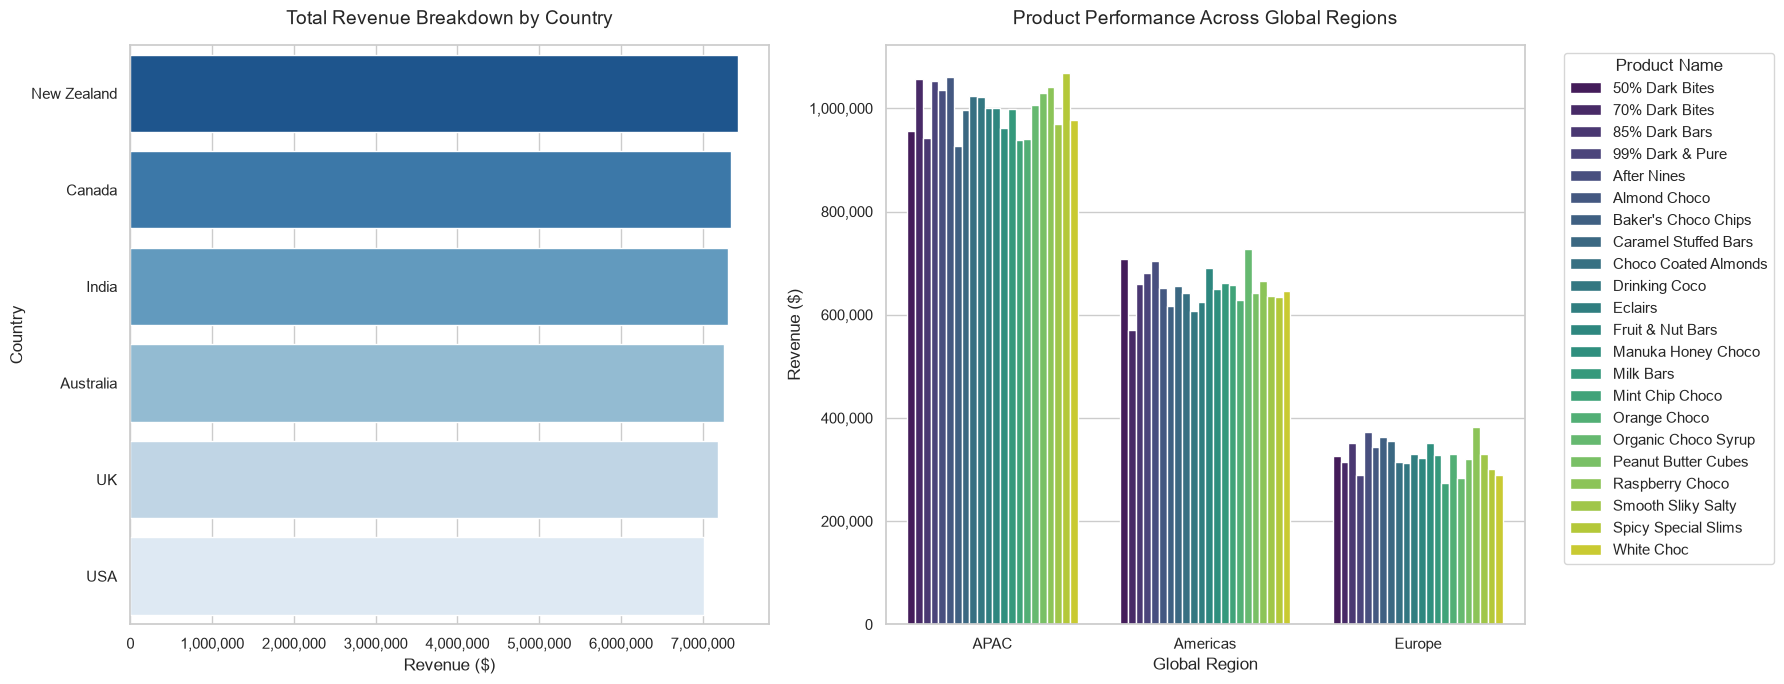

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure standard clean visual styling
sns.set_theme(style="whitegrid")

# Create a multi-plot layout (1 row, 2 columns for a clean dashboard look)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =====================================================================
# VISUALIZATION 1: Total Revenue by Country (Geo_y)
# =====================================================================
# Aggregate data for clean sorting
country_sales = df.groupby('Geo_y')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False)

sns.barplot(
    ax=axes[0],
    data=country_sales,
    x='Amount',
    y='Geo_y',
    palette='Blues_r',
    hue='Geo_y',
    legend=False
)
axes[0].set_title('Total Revenue Breakdown by Country', fontsize=14, pad=15)
axes[0].set_xlabel('Revenue ($)', fontsize=12)
axes[0].set_ylabel('Country', fontsize=12)

# Format x-axis with commas for readability
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))


# =====================================================================
# VISUALIZATION 2: Regional Performance & Product Distribution
# =====================================================================
# Aggregate by Region and Product Category/Name to see global market trends
region_prod_sales = df.groupby(['Region', 'Product_y'])['Amount'].sum().reset_index()

sns.barplot(
    ax=axes[1],
    data=region_prod_sales,
    x='Region',
    y='Amount',
    hue='Product_y',
    palette='viridis'
)
axes[1].set_title('Product Performance Across Global Regions', fontsize=14, pad=15)
axes[1].set_xlabel('Global Region', fontsize=12)
axes[1].set_ylabel('Revenue ($)', fontsize=12)
axes[1].legend(title='Product Name', bbox_to_anchor=(1.05, 1), loc='upper left')

# Format y-axis with commas for readability
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y))))


# =====================================================================
# FINAL LAYOUT ADJUSTMENTS
# =====================================================================
plt.tight_layout()
plt.show()